# Cancer Genetics için Principal Component Analysis

**Ders:** Lineer Cebir ve Algoritmaları &nbsp;•&nbsp; **Konu:** Principal Component Analysis (PCA) &nbsp;•&nbsp; **Uygulama Alanı:** Cancer Genomics

Bu notebook, PCA'yı saf bir matris ayrıştırma tekniği olarak değil, **yüksek boyutlu biyolojik verinin geometrik yapısını ortaya çıkaran** bir araç olarak ele alır. İki tamamlayıcı veri seti üzerinde çalışacağız:

1. **TCGA-PANCAN-HiSeq** — 5 farklı kanser tipi için RNA-seq gene expression verisi. Boyut: $801 \times 20531$. Burada $p \gg n$ olduğu için PCA neredeyse zorunlu bir ön işlemdir.
2. **Breast Cancer Wisconsin Diagnostic (WDBC)** — Hücre çekirdeği morfolojisinden çıkarılmış 30 klinik özellik, 569 örnek. Burada $p < n$ ve PCA daha çok yorumlanabilirlik için kullanılır.

Bu iki veri seti birlikte, PCA'nın **"binlerce gen arasında gizli yapı arama"** ve **"az sayıda klinik özellik arasında ortogonal ekseni bulma"** olmak üzere iki farklı kullanım rejimini de görmemizi sağlar.

Akış: önce PCA'nın matematiksel temelleri (eigendecomposition + SVD), sonra NumPy ile sıfırdan implementasyon, sonra her iki veri setinde uygulama, en sonunda karşılaştırmalı analiz.

# Bölüm 0 — Kütüphaneler ve Sabitler

Bu bölümde notebook boyunca kullanılacak tüm bağımlılıkları **tek bir blokta**, alfabetik sırada içe aktarıyoruz. Bu, bağımlılıkların tek bir yerden takip edilmesini ve eksik paketlerin baştan tespit edilmesini sağlar.

Sabitler de aynı şekilde tek bir yerde tanımlanır. `RANDOM_STATE`, tüm stokastik adımlarda (örneğin `KNeighborsClassifier` öncesi `train_test_split`, `cross_val_score` katlamaları) **deterministik sonuçlar** elde etmek için sabitlenmiştir. `N_COMPONENTS = 10`, PCA için varsayılan üst sınırımızdır; ihtiyaca göre yerel olarak değiştirilebilir. Renk paletleri, sınıflar arası görsel tutarlılık için her plotta aynı kanser tipine aynı rengi atayacaktır.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_COMPONENTS = 10

CANCER_COLORS = {
    'BRCA': '#E74C3C',
    'COAD': '#3498DB',
    'KIRC': '#2ECC71',
    'LUAD': '#F39C12',
    'PRAD': '#9B59B6',
}
WDBC_COLORS = {'M': '#E74C3C', 'B': '#2ECC71'}

TCGA_DATA_PATH = './TCGA-PANCAN-HiSeq-801x20531/data.csv'
TCGA_LABELS_PATH = './TCGA-PANCAN-HiSeq-801x20531/labels.csv'
WDBC_DATA_PATH = './breast+cancer+wisconsin+diagnostic/wdbc.data'

np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Bölüm 1 — PCA'nın Matematiksel Temelleri

PCA, bir veri matrisinin kovaryans yapısının **eigendecomposition**'ına (veya eşdeğer olarak veri matrisinin **SVD**'sine) dayanan, doğrusal bir boyut indirgeme tekniğidir. Bu bölüm, PCA'yı dört farklı açıdan inşa eder: (i) **probleme motivasyon** — neden buna ihtiyacımız var, (ii) **optimizasyon formülasyonu** — PCA tam olarak hangi problemi çözer, (iii) **algoritmik gerçekleştirim** — pratikte nasıl hesaplanır (SVD), ve (iv) **yorumlama** — sonuçları nasıl okuruz (explained variance, loadings). Tüm uygulama bölümleri bu kavramların dilini kullanacak; bu nedenle önce sözlüğü inşa ediyoruz.

## 1.1 — Boyut Lanetinin Biyoinformatikte Anlamı

Modern RNA-seq teknolojisi tek bir tümör örneğinde **20.000'i aşkın gen**in ifade seviyesini eş zamanlı ölçer. Bunun sebebi biyolojik: hangi genin hangi kanser tipinde rol oynadığı *önceden* bilinmez. Bu nedenle deney boşaltıcı bir şekilde her şeyi ölçer ve sınıflandırıcı analiz sonraya bırakılır.

Sonuç, TCGA-PANCAN veri setinde olduğu gibi şu boyutlu bir matristir:

$$X \in \mathbb{R}^{n \times p}, \quad n = 801, \quad p = 20{,}531.$$

Burada $p \gg n$, yani **özellik sayısı örnek sayısından çok daha büyük**. Bu rejim, klasik istatistiğin sessizce varsaydığı $n \gg p$ durumunun tam tersidir ve şu pratik sorunlara yol açar:

1. **Singular covariance matrix.** $S = \tfrac{1}{n-1} X^\top X$ ampirik kovaryans matrisi $p \times p$ boyutludur ama rankı $\min(n,p) = n-1 = 800$ ile sınırlıdır. Yani $S$ **tekildir**, doğrudan tersi alınamaz, dolayısıyla LDA, lineer regresyon vb. klasik yöntemler bozulur.
2. **Concentration of distances.** Yüksek boyutta uzaklıklar birbirine yakınsar: $\frac{\max_j \lVert x_i - x_j \rVert - \min_j \lVert x_i - x_j \rVert}{\min_j \lVert x_i - x_j \rVert} \to 0$. Bu, KNN gibi mesafeye dayalı yöntemleri etkisizleştirir.
3. **Görsel sezgi başarısız olur.** Rastgele iki gen seçip $(g_i, g_j)$ düzleminde sınıfları görmeye çalışmak neredeyse hiçbir zaman ayrışma vermez — çünkü bilgi *belirli iki gende* değil, *binlerce genin lineer kombinasyonunda* saklıdır.

**Feature Selection** (örneğin yüksek varyanslı $k$ geni elde tutmak) sadece var olan ekseni filtreler. **Feature Extraction** (PCA, ICA, autoencoder) ise **yeni eksenler** üretir — orijinal genlerin lineer kombinasyonları olarak. PCA, bu yeni eksenleri *varyansı maksimize edecek* şekilde seçer; bu seçimin neden "bilgi açısından" doğru olduğunu 1.2'de göreceğiz.

Aşağıda 1. madde olan **rastgele iki gende sınıfların ayrışmaması** sezgisini somut hale getiriyoruz.

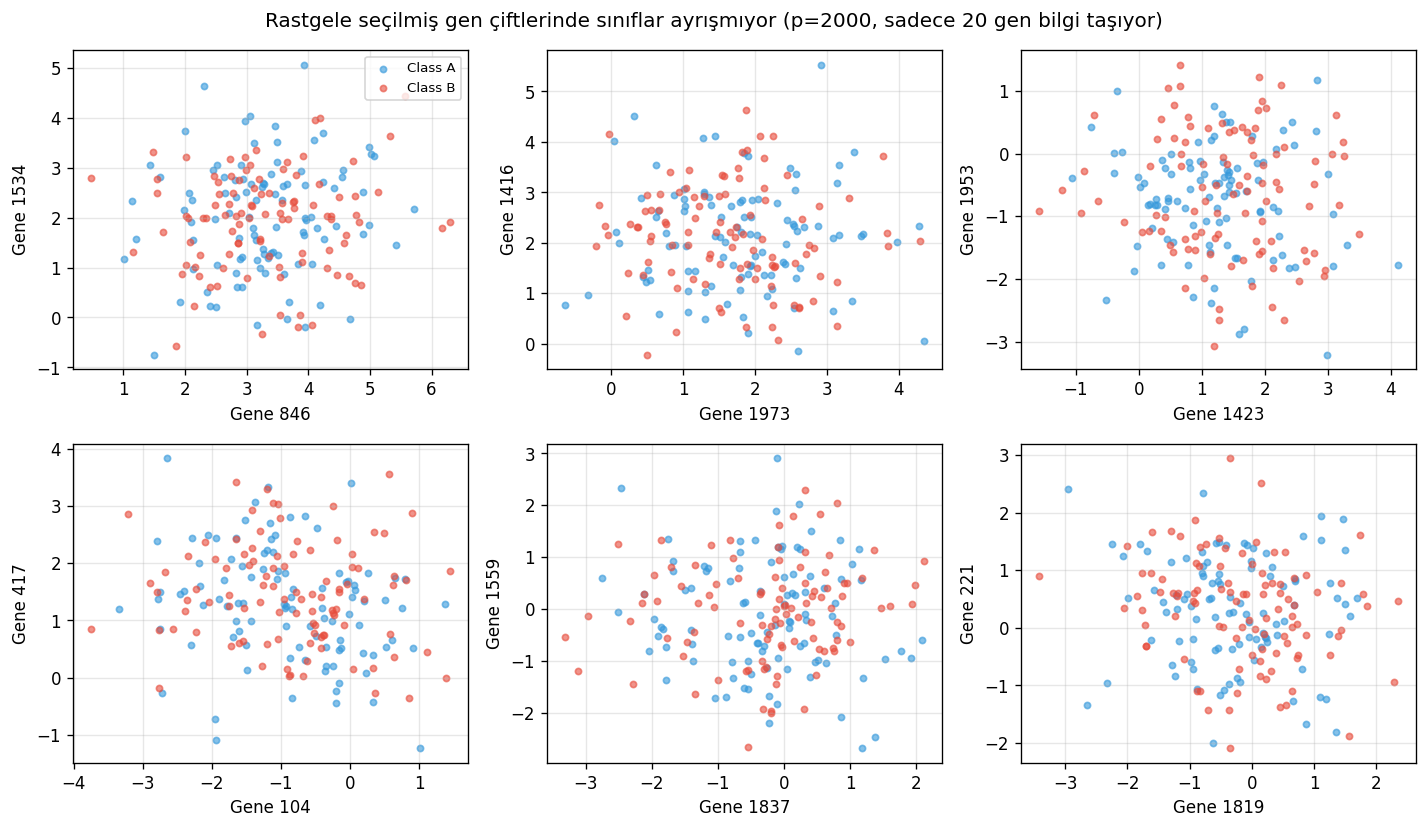

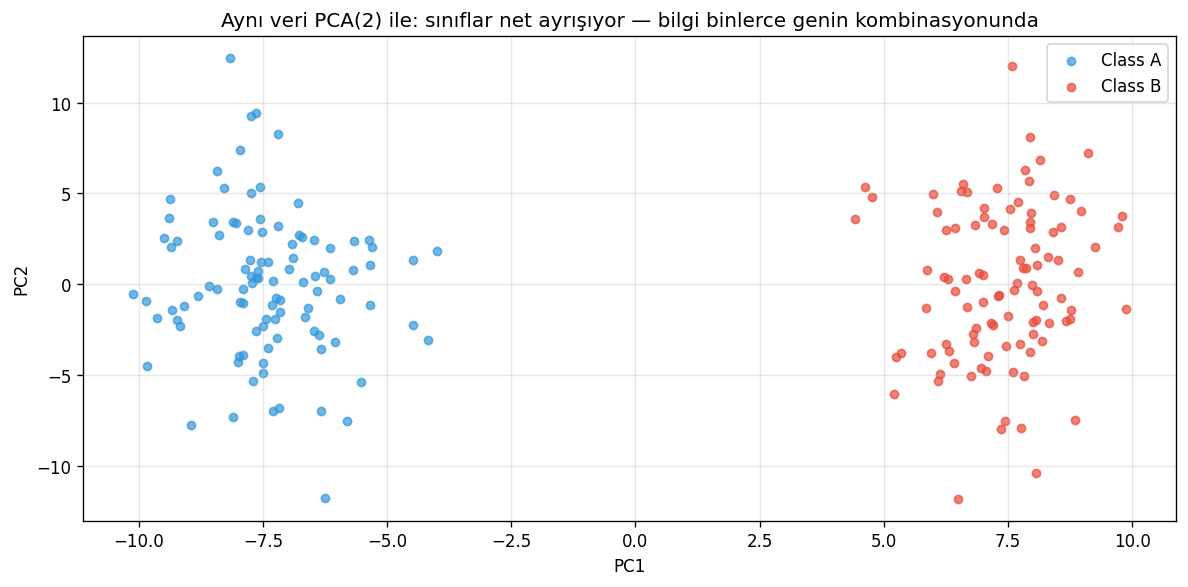

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
n_per_class = 100
p_genes = 2000

mu_a = rng.normal(0, 1, p_genes)
mu_b = mu_a.copy()
informative_idx = rng.choice(p_genes, size=20, replace=False)
mu_b[informative_idx] += 3.0

X_a = rng.normal(mu_a, 1.0, (n_per_class, p_genes))
X_b = rng.normal(mu_b, 1.0, (n_per_class, p_genes))
X_demo = np.vstack([X_a, X_b])
y_demo = np.array([0] * n_per_class + [1] * n_per_class)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax in axes.ravel():
    i, j = rng.choice(p_genes, size=2, replace=False)
    ax.scatter(X_demo[y_demo == 0, i], X_demo[y_demo == 0, j], s=14, alpha=0.6, c='#3498DB', label='Class A')
    ax.scatter(X_demo[y_demo == 1, i], X_demo[y_demo == 1, j], s=14, alpha=0.6, c='#E74C3C', label='Class B')
    ax.set_xlabel(f'Gene {i}')
    ax.set_ylabel(f'Gene {j}')

axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Rastgele seçilmiş gen çiftlerinde sınıflar ayrışmıyor (p=2000, sadece 20 gen bilgi taşıyor)')
fig.tight_layout()
plt.show()

pca_demo = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_demo)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pca_demo[y_demo == 0, 0], pca_demo[y_demo == 0, 1], s=24, alpha=0.7, c='#3498DB', label='Class A')
ax.scatter(pca_demo[y_demo == 1, 0], pca_demo[y_demo == 1, 1], s=24, alpha=0.7, c='#E74C3C', label='Class B')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Aynı veri PCA(2) ile: sınıflar net ayrışıyor — bilgi binlerce genin kombinasyonunda')
ax.legend()
fig.tight_layout()
plt.show()

Üstteki ızgarada **6 rastgele gen çiftinin hiçbiri** iki sınıfı ayırt edemiyor; çünkü bilgi taşıyan 20 genin rastgele bir çifte düşme olasılığı pratikte sıfır. Alttaki tek PCA projeksiyonu ise sınıfları derhal ayırıyor — çünkü PC1, bilgi taşıyan 20 genin **lineer kombinasyonu** olarak otomatik ortaya çıkıyor. Bu, PCA'nın neden feature selection'dan üstün bir feature extraction tekniği olduğunun çıplak gözle görülebilen kanıtıdır.

## 1.2 — PCA: Bir Optimizasyon Problemi Olarak

PCA'yı tanımlamanın en temiz yolu, onu bir **varyans-maksimizasyonu** problemi olarak yazmaktır. Veri matrisimiz $X \in \mathbb{R}^{n \times p}$ olsun ve sütunları **merkezlenmiş** kabul edelim:

$$\tilde{X} = X - \mathbf{1}_n \bar{x}^\top, \quad \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \in \mathbb{R}^p.$$

Merkezleme şarttır; çünkü PCA, orijini geçen yönleri arar. Aksi durumda "en büyük varyans yönü" verinin ortalamasına doğru bir vektör tarafından domine edilebilir. Merkezleme sonrası **ampirik covariance matrix**:

$$S = \frac{1}{n-1} \tilde{X}^\top \tilde{X} \in \mathbb{R}^{p \times p}.$$

$S$ simetrik ve pozitif yarı-tanımlıdır (PSD), dolayısıyla **gerçek ve negatif olmayan eigenvalue**'lara ve **ortogonal eigenvector**'lere sahiptir (spektral teorem).

### Birinci Principal Component

Birinci principal component, veriyi üzerine projekte ettiğimizde **varyansı maksimize eden** birim vektördür. Bir birim vektör $v \in \mathbb{R}^p$ için projeksiyon skorları $\tilde{X} v \in \mathbb{R}^n$ ve bu skorların varyansı:

$$\mathrm{Var}(\tilde{X} v) = \frac{1}{n-1} \lVert \tilde{X} v \rVert^2 = \frac{1}{n-1} v^\top \tilde{X}^\top \tilde{X} v = v^\top S v.$$

Buradan optimizasyon problemi:

$$\boxed{\; v_1 \;=\; \arg\max_{v \in \mathbb{R}^p} \; v^\top S v \quad \text{s.t.} \quad \lVert v \rVert_2 = 1. \;}$$

Kısıt olmadan $v^\top S v$ sınırsızdır (ölçekleme ile büyütülebilir), bu yüzden $\lVert v \rVert = 1$ şarttır.

### Lagrangian ve Eigenvalue Probleminin Doğuşu

Lagrangian:

$$\mathcal{L}(v, \lambda) = v^\top S v - \lambda (v^\top v - 1).$$

Stasyoner nokta için $\nabla_v \mathcal{L} = 0$:

$$2 S v - 2 \lambda v = 0 \;\;\Longrightarrow\;\; \boxed{\; S v = \lambda v. \;}$$

Yani **stasyoner noktalar $S$'in eigenvektörleridir**. Hangi eigenvektör maksimumu verir? Hedef fonksiyonu değerlendirelim: $v^\top S v = v^\top (\lambda v) = \lambda \lVert v \rVert^2 = \lambda$. Demek ki maksimum, **en büyük eigenvalue**'ya karşılık gelen eigenvektörde elde edilir. Bu vektöre $v_1$, eigenvalue'ya $\lambda_1$ diyoruz; birinci PC'nin örnek varyansı tam olarak $\lambda_1$'dir.

### Sonraki Componentler: Sıralı Kısıtlı Maksimizasyon

$k$. principal component, **önceki tüm componentlere ortogonal** olan birim vektörler arasında varyansı maksimize eder:

$$v_k \;=\; \arg\max_{v} \; v^\top S v \quad \text{s.t.} \quad \lVert v \rVert = 1, \;\; v \perp v_1, \ldots, v_{k-1}.$$

Aynı Lagrangian argümanı ile bu, $S$'in **$k$. en büyük eigenvalue**'sina karşılık gelen eigenvektörüdür. Spektral teorem zaten farklı eigenvalue'lara ait eigenvektörlerin otomatik ortogonal olduğunu garanti eder; aynı eigenvalue'nun katlılığı varsa Gram–Schmidt ile ortogonalize edilebilir. Sonuç olarak PCA, $S$'in **tüm spektrumunu** verir:

$$S = V \Lambda V^\top, \quad V = [v_1 \mid v_2 \mid \cdots \mid v_p], \quad \Lambda = \mathrm{diag}(\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0).$$

### Geometrik Yorum

$v_1, \ldots, v_p$ ortogonal bir tabandır; veriyi bu tabanda yeniden yazmak bir **rotation**'dır. PCA bilgi kaybı yapmaz — $p$ component tutarsanız orijinal veriyi mükemmel geri alırsınız. "Boyut indirgeme" sadece ilk $k$ component'i kullanıp gerisini atmaktır; bu, veriyi $v_1, \ldots, v_k$ tarafından gerilen $k$-boyutlu altuzaya **dik projeksiyon**'dur ve **rank-$k$ approximation** olarak da bilinir.

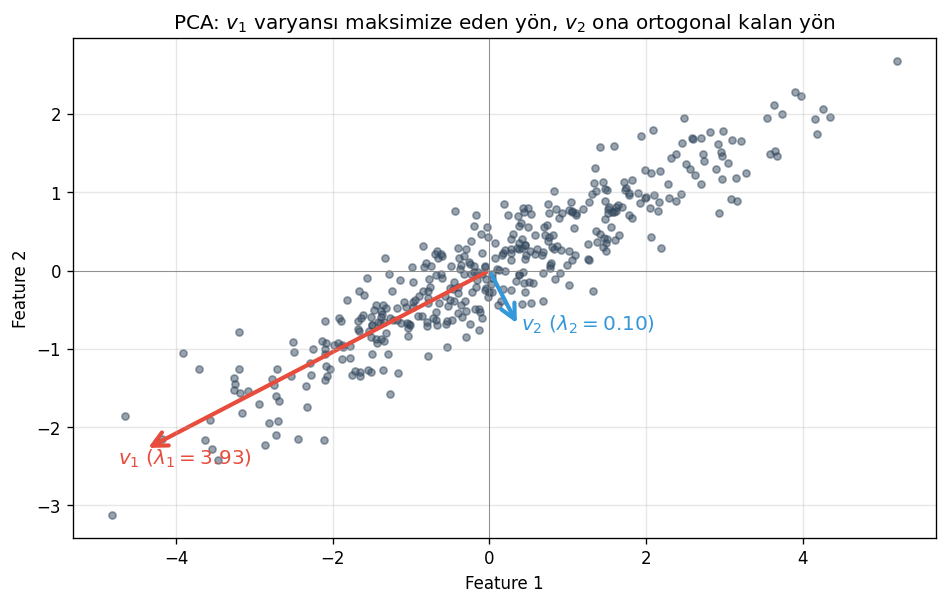

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
cov_demo = np.array([[3.0, 1.6], [1.6, 1.0]])
X_2d = rng.multivariate_normal(mean=[0, 0], cov=cov_demo, size=400)

S_demo = np.cov(X_2d, rowvar=False)
eigvals_demo, eigvecs_demo = np.linalg.eigh(S_demo)
order = np.argsort(eigvals_demo)[::-1]
eigvals_demo, eigvecs_demo = eigvals_demo[order], eigvecs_demo[:, order]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=18, alpha=0.5, c='#34495E')
for i, color in zip(range(2), ['#E74C3C', '#3498DB']):
    end = eigvecs_demo[:, i] * np.sqrt(eigvals_demo[i]) * 2.5
    arrow = FancyArrowPatch((0, 0), tuple(end), arrowstyle='->', mutation_scale=22, color=color, lw=2.5)
    ax.add_patch(arrow)
    ax.text(end[0] * 1.08, end[1] * 1.08, f'$v_{i+1}$ ($\\lambda_{i+1}={eigvals_demo[i]:.2f}$)', color=color, fontsize=12)

ax.set_aspect('equal')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('PCA: $v_1$ varyansı maksimize eden yön, $v_2$ ona ortogonal kalan yön')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
fig.tight_layout()
plt.show()

Yukarıdaki 2B örnekte $v_1$, eliptik bulutun **uzun ekseni** boyunca uzanır; bu eksen üzerindeki projeksiyon varyansı $\lambda_1$'dir. $v_2$ ona ortogonaldir ve geri kalan varyansı ($\lambda_2$) taşır. Yüksek boyutta da geometri aynıdır, sadece çizilemez: PCA verinin **kovaryans elipsoidinin** ana eksenlerini bulur.

## 1.3 — SVD ile Bağlantı

PCA'yı $S$'in eigendecomposition'ı olarak tanımlamak teorik olarak temiz ama **pratikte sorunludur**: $p = 20{,}531$ için $S$ matrisi $p \times p = 20{,}531 \times 20{,}531 \approx 4.2 \cdot 10^8$ kayan-nokta hücresi içerir (yaklaşık 3 GB float64). Üstüne üstlük $S$'i hesaplarken $X^\top X$ çarpımı **conditioning sayısını kareler**, küçük singular value'lar yuvarlama hatalarında kaybolur. Bu nedenle gerçek implementasyonlar (NumPy, SciPy, scikit-learn) PCA'yı **Singular Value Decomposition (SVD)** üzerinden hesaplar.

### SVD Tanımı

Herhangi bir reel $\tilde{X} \in \mathbb{R}^{n \times p}$ matrisi için thin SVD:

$$\tilde{X} = U \Sigma V^\top, \quad U \in \mathbb{R}^{n \times r}, \;\; \Sigma \in \mathbb{R}^{r \times r}, \;\; V \in \mathbb{R}^{p \times r}, \quad r = \min(n, p).$$

Burada $U^\top U = V^\top V = I_r$ ve $\Sigma = \mathrm{diag}(\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r \geq 0)$.

### SVD ↔ Eigendecomposition İlişkisi

$\tilde{X} = U \Sigma V^\top$ ifadesini $S$'in tanımına koyalım:

$$S = \frac{1}{n-1} \tilde{X}^\top \tilde{X} = \frac{1}{n-1} (V \Sigma U^\top)(U \Sigma V^\top) = V \left( \frac{\Sigma^2}{n-1} \right) V^\top.$$

Bu ifadeyi $S = V \Lambda V^\top$ ile karşılaştırınca:

$$\boxed{\; \lambda_k = \frac{\sigma_k^2}{n-1}, \quad v_k = V_{:,k}. \;}$$

Yani **principal component'ler $\tilde{X}$'in sağ singular vektörleridir** ve eigenvalue'lar singular value'ların karelerinin $(n-1)$'e bölünmüş halidir. PC skorları için ek bir kimlik:

$$\tilde{X} V = U \Sigma \;\;\Longrightarrow\;\; \text{skorlar} = U \Sigma.$$

### Neden SVD Daha İyi?

1. **Numerik kararlılık.** Eigendecomposition için $\tilde{X}^\top \tilde{X}$ inşa etmek conditioning sayısını $\kappa(\tilde{X})^2$'ye yükseltir. SVD doğrudan $\tilde{X}$ üzerinde çalıştığı için $\kappa(\tilde{X})$ ile sınırlıdır — özellikle yakın-tekil veride çok daha güvenlidir.
2. **$p \gg n$ verimliliği.** $S \in \mathbb{R}^{p \times p}$ matrisini kurmak $\mathcal{O}(np^2)$ zaman ve $\mathcal{O}(p^2)$ bellek ister; ancak $\tilde{X}$ matrisinin SVD'si $\mathcal{O}(\min(n,p)^2 \cdot \max(n,p))$ zamanda hesaplanır. TCGA için $n=801, p=20531$:
   - Eigendecomposition: $\mathcal{O}(801 \cdot 20531^2) \approx 3.4 \cdot 10^{11}$
   - SVD: $\mathcal{O}(801^2 \cdot 20531) \approx 1.3 \cdot 10^{10}$

   Yaklaşık **25 kat hız farkı** ve **kuadratik bellek tasarrufu** (yaklaşık 3 GB yerine birkaç yüz MB).
3. **Truncated/randomized SVD.** Sadece en büyük $k$ singular value'ya ihtiyacımız varsa, randomized SVD $\mathcal{O}(np k)$ zamanda iş bitirir. sklearn'ün `PCA(svd_solver='randomized')` seçeneği tam olarak bunu yapar — TCGA gibi gen ekspresyon matrislerinde varsayılan tercihtir.

### Sınıfta İşlenmeyen Pratik İpucu

$p \gg n$ durumunda $X^\top X$ yerine **$X X^\top \in \mathbb{R}^{n \times n}$** (Gram matrisi) üzerinden eigendecomposition yapmak da bir alternatif: bu çok daha küçük matrisin eigenvectorleri $U$'yu verir; $V$ ise $V = \tfrac{1}{\sigma_k} \tilde{X}^\top u_k$ formülüyle yeniden inşa edilir. Bu trick, scikit-learn'ün eski sürümlerinde **dual PCA** olarak yer alıyordu ve hâlâ kernel PCA'nın özüdür.

## 1.4 — Açıklanan Varyans Oranı

PCA bir dizi yeni eksen üretir; sonraki soru: bunlardan **kaçını tutmalıyız**? Cevap, her bir bileşenin verideki toplam varyansın ne kadarını yakaladığına bakmakla başlar.

### Toplam Varyans = İz

Verideki toplam varyans, her özelliğin varyansının toplamıdır; bu ise $S$'in iz'idir:

$$\mathrm{TotalVar}(X) = \sum_{j=1}^{p} \mathrm{Var}(X_{:,j}) = \mathrm{tr}(S) = \sum_{k=1}^{p} \lambda_k.$$

Son eşitlik spektral teoremin doğrudan sonucudur: iz, eigenvalue'ların toplamına eşittir. Yani **eigenvalue'lar verinin varyansını parsellerler**.

### Proportion of Variance Explained (PVE)

$k$. principal component'in açıkladığı varyans oranı:

$$\boxed{\; \mathrm{PVE}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}. \;}$$

Kümülatif PVE:

$$\mathrm{CumPVE}(k) = \sum_{i=1}^{k} \mathrm{PVE}_i = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{p} \lambda_j}.$$

Pratik kural: ilk $k$ bileşeni toplam varyansın **%80–%95** arasını açıklayacak şekilde seçmek. Hedef oran uygulama alanına bağlıdır — görselleştirme için $k = 2$ veya $3$ zorunludur (varyans az olsa bile), ama downstream supervised model için kümülatif PVE eşik olarak kullanılır.

### Scree Plot ve "Dirsek" Kuralı

**Scree plot**: $k$'ya karşı $\lambda_k$ (veya $\mathrm{PVE}_k$) çubuğu. Tipik şekil: hızlıca düşen ilk birkaç değer, ardından **uzun bir düz kuyruk**. Düz kısma giriş noktasındaki "dirsek" (elbow), sinyalin gürültüden ayrıldığı yer olarak yorumlanır.

### Kaiser Kriteri vs. Kırılma Noktası

İki popüler eşik kuralı:

| Kural | Tanım | Avantaj | Dezavantaj |
| --- | --- | --- | --- |
| **Kaiser** | $\lambda_k > 1$ olan tüm $k$'leri tut (correlation PCA için) | Otomatik, parametresiz | Genellikle çok az veya çok fazla bileşen seçer; teorik temeli zayıf |
| **Elbow** | Scree plot'ta eğimin değiştiği noktaya kadar tut | Veri-spesifik, dirseği görsel olarak ayırt etmek kolaydır | Sübjektif, kıvrım keskin değilse belirsiz |
| **Kümülatif PVE eşiği** | $\mathrm{CumPVE}(k) \geq 0.90$ olan en küçük $k$ | Yorumlanabilir, raporlanabilir | Eşik (%80, %90, %95) keyfi |

Pratikte üçünü birden raporlamak ve **downstream görev performansıyla** (örneğin bu projede KNN cross-validation accuracy) doğrulamak en sağlam yaklaşımdır. Bölüm 3.6 ve 4.4'te tam olarak bunu yapacağız.

## 1.5 — Covariance PCA vs. Correlation PCA

PCA'yı uygulamadan önce verinin **standardize edilip edilmeyeceği** kritik bir karardır ve uygulamada iki farklı PCA türü ortaya çıkarır:

- **Covariance PCA** — sadece merkezlenmiş veri üzerinde çalışır:
  $$\tilde{X}_{ij} = X_{ij} - \bar{X}_{:,j}, \quad S_{\text{cov}} = \frac{1}{n-1} \tilde{X}^\top \tilde{X}.$$
  Özelliklerin **orijinal birimleri ve ölçekleri korunur**. Büyük varyanslı özellikler eigendecomposition'a daha çok katkıda bulunur.
- **Correlation PCA** — merkezleme + birim varyansa ölçekleme yapılır:
  $$Z_{ij} = \frac{X_{ij} - \bar{X}_{:,j}}{\hat{\sigma}_j}, \quad S_{\text{cor}} = \frac{1}{n-1} Z^\top Z.$$
  Her özellik varyans olarak eşitlenir; sonuç $S_{\text{cor}}$ ise tam olarak orijinal $X$'in **correlation matrix**'idir, diyagonali tüm 1'lerden oluşur.

### Karar Kriteri Tablosu

| Soru | Covariance PCA | Correlation PCA |
| --- | --- | --- |
| Tüm özellikler aynı birimde mi? | Evet → tercih | Hayır → kullanma |
| Özellik varyansları **biyolojik anlam** taşıyor mu? | Evet → tercih (varyans bilgidir) | Hayır → daha az risk |
| Özellikler farklı birimlerde mi (m, kg, °C, ...)? | Hayır → birimce büyük olan domine eder | Evet → tercih (birim-bağımsız) |
| Outlier'lara duyarlılık? | Yüksek (varyans karesel) | Yüksek (z-skor de outlier'a duyarlı) |
| sklearn karşılığı | `PCA().fit(X)` | `PCA().fit(StandardScaler().fit_transform(X))` |

### Gene Expression için Hangisi?

RNA-seq verisinde tüm gen değerleri **aynı birimde** ölçülür (typically log-normalized RPKM/TPM veya FPKM). Üstelik gen varyansındaki farklılıklar **biyolojik bilgi taşır**: housekeeping gen düşük varyanslı, marker gen yüksek varyanslı olur. Correlation PCA bu bilgiyi siler ve her geni eşit ağırlıkla muamele eder, bu da genellikle istemediğimiz bir şeydir. Sonuç olarak **gene expression için varsayılan tercih covariance PCA**'dır.

### WDBC için Hangisi?

WDBC'de özellikler farklı doğaya sahip: `area_mean` (yüzlerce piksel²) ile `smoothness_mean` (0–1 arası oran) aynı ölçekte değil. Bu durumda **correlation PCA daha güvenli varsayılan tercihtir**, aksi takdirde `area_mean` PC1'i tek başına şekillendirebilir. Bölüm 4'te her ikisini de uygulayıp sayısal olarak göstereceğiz.

### Matematiksel Fark — Ne Değişiyor?

Standardizasyon, $\tilde{X}$'i $Z = \tilde{X} D^{-1}$ ile çarpmaktır ($D = \mathrm{diag}(\hat{\sigma}_1, \ldots, \hat{\sigma}_p)$). Bu, **bir özellik-uzayında lineer dönüşüm**dür; ne bir rotation ne de bir öteleme. Sonuçta eigenvektörler de eigenvalue'lar da değişir; iki yöntemin sonuçları **birbirinden basit bir formülle elde edilemez**. Yani "hangisini kullanacağız" sorusunun cevabı tamamen veriyi nasıl yorumladığımıza bağlıdır.

### Bölüm 1 Özeti

Şu noktada elimizde PCA için tam bir matematiksel sözlük var:

1. **Problem**: $p \gg n$ olan biyolojik verinin görselleştirilemez ve gürültülü yapısı.
2. **Formülasyon**: $v_1 = \arg\max_{\lVert v \rVert = 1} v^\top S v$, Lagrangian ile eigenvalue problemine eşdeğer.
3. **Hesaplama**: $\tilde{X}$ üzerinde SVD; $\lambda_k = \sigma_k^2 / (n-1)$, skorlar $U \Sigma$.
4. **Yorum**: PVE ve cumulative PVE; scree plot ile bileşen sayısını seçme.
5. **Önişleme tercihi**: gene expression için covariance, heterojen klinik özellikler için correlation PCA.

Sonraki bölümde bu denklemleri NumPy ile **sıfırdan** yazıp `sklearn.decomposition.PCA` ile karşılaştıracağız.